In [ ]:
# FAZA 5 — Modelovanje: duboki modeli (LSTM, GRU, Transformer)
#
# Koristim isti finalni skup atributa i istu vremensku podelu (train/valid/test)
# kao u Fazi 4, ali podatke organizujem u sekvence po entitetu, poredjane
# hronološki po vremenskom prozoru. LSTM, GRU i Transformer ne dobijaju
# ručno napravljene istorijske atribute jedan po jedan (kao klasični modeli),
# već čitav niz prethodnih prozora, pa sami uče vremenski obrazac.
#
# Sva tri modela se treniraju i evaluiraju na potpuno isti način (ista
# funkcija za treniranje, ista funkcija za evaluaciju, ista mera za
# disbalans klasa), da bi poređenje bilo pravedno.

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
)

warnings.filterwarnings("ignore")

PROC = Path(__file__).resolve().parent.parent / "data" / "processed"
RESULTS = Path(__file__).resolve().parent.parent / "results"
MODELS = Path(__file__).resolve().parent.parent / "models"
RESULTS.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)

SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Uređaj za treniranje:", DEVICE)

Uređaj za treniranje: cpu


In [ ]:
# --- 1. Učitavanje podataka iz Faze 3 (isti izvor kao kod klasičnih modela) ---
vremenski_prozori = pd.read_parquet(PROC / "features.parquet")

with open(PROC / "selected_features.json", encoding="utf-8") as f:
    atributi_final = json.load(f)
with open(PROC / "imputation_values.json", encoding="utf-8") as f:
    imputation_values = json.load(f)

# Imputacija istim vrednostima izračunatim na treningu u Fazi 3.
for kolona, vrednost in imputation_values.items():
    if kolona in vremenski_prozori.columns:
        vremenski_prozori[kolona] = vremenski_prozori[kolona].fillna(vrednost)

print("Ukupno redova:", len(vremenski_prozori))
print(f"Finalni skup atributa ({len(atributi_final)}):", atributi_final)

Ukupno redova: 224180
Finalni skup atributa (11): ['day_of_week', 'events_per_dst', 'hour_of_day', 'n_dst_seen_before', 'n_ntlm', 'n_ntlm_delta', 'n_ntlm_ma24', 'n_ntlm_z', 'new_dst_ratio', 'ntlm_ratio', 'window_seq_num']


In [ ]:
# --- 2. Skaliranje atributa ---
# RobustScaler se uči isključivo na treningu, da ne bi došlo do curenja
# informacija iz validacije/testa, isto pravilo kao u prethodnim fazama.
skaler = RobustScaler()
trening_maska = vremenski_prozori["split"] == "train"
skaler.fit(vremenski_prozori.loc[trening_maska, atributi_final])
vremenski_prozori[atributi_final] = skaler.transform(vremenski_prozori[atributi_final])

In [ ]:
# --- 3. Pravljenje sekvenci po entitetu ---
# LSTM, GRU i Transformer očekuju ulaz oblika (batch, koraci, atributi).
# Za svaki red (trenutni prozor) pravim sekvencu od SEQ_LEN uzastopnih
# prozora istog entiteta, računajući unazad i uključujući trenutni prozor.
# Ako entitet nema dovoljno istorije, sekvenca se popunjava nulama sa leve
# strane (padding), pa svaka sekvenca ima istu dužinu.

SEQ_LEN = 10  # broj uzastopnih vremenskih prozora u jednoj sekvenci


def napravi_sekvence(df, kolone, seq_len):
    """Vraća (df sortiran po entity+window_id, niz oblika (n_redova, seq_len, n_atributa))."""
    df = df.sort_values(["entity", "window_id"]).reset_index(drop=True)
    vrednosti = df[kolone].to_numpy(dtype=np.float32)
    sekvence = np.zeros((len(df), seq_len, len(kolone)), dtype=np.float32)

    for _, grupa in df.groupby("entity", sort=False):
        idx = grupa.index.to_numpy()
        podaci_entiteta = vrednosti[idx]
        for i in range(len(idx)):
            pocetak = max(0, i - seq_len + 1)
            deo_istorije = podaci_entiteta[pocetak : i + 1]
            sekvence[idx[i], seq_len - len(deo_istorije) :, :] = deo_istorije

    return df, sekvence


vremenski_prozori, X_sve = napravi_sekvence(vremenski_prozori, atributi_final, SEQ_LEN)
print("Oblik sekvenci za sve redove:", X_sve.shape)

# Oblik (224180, 10, 11) potvrđuje: svaki od 224180 prozora dobija sekvencu
# od 10 prethodnih koraka × 11 atributa. Entiteti sa manje od 10 prethodnih
# prozora imaju sekvencu popunjenu nulama sa leve strane (padding). Ovo
# uključuje i sve entitete na početku njihove istorije (window_seq_num < 10).

Oblik sekvenci za sve redove: (224180, 10, 11)


In [ ]:
# --- 4. Podela na train/val/test (ista podela kao u Fazi 4, kolona 'split') ---
train_maska = (vremenski_prozori["split"] == "train").to_numpy()
val_maska = (vremenski_prozori["split"] == "valid").to_numpy()
test_maska = (vremenski_prozori["split"] == "test").to_numpy()

X_train = X_sve[train_maska]
X_val = X_sve[val_maska]
X_test = X_sve[test_maska]

y_train = vremenski_prozori.loc[train_maska, "is_attack"].reset_index(drop=True)
y_val = vremenski_prozori.loc[val_maska, "is_attack"].reset_index(drop=True)
y_test = vremenski_prozori.loc[test_maska, "is_attack"].reset_index(drop=True)

print(f"train: {X_train.shape}, pozitivnih: {int(y_train.sum())}")
print(f"val:   {X_val.shape}, pozitivnih: {int(y_val.sum())}")
print(f"test:  {X_test.shape}, pozitivnih: {int(y_test.sum())}")

# Isti brojevi pozitivnih kao u Fazi 4 (101/115/35).
# Vremenska podela identična, sekvence samo menjaju oblik ulaza,
# ne diraju raspodelu redova po skupovima.

train: (45685, 10, 11), pozitivnih: 101
val:   (17630, 10, 11), pozitivnih: 115
test:  (160865, 10, 11), pozitivnih: 35


In [ ]:
# --- 5. PyTorch Dataset i DataLoader ---
class ProzorDataset(Dataset):
    """Jedan primer = jedna sekvenca prozora (X) i oznaka poslednjeg prozora (y)."""

    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y.to_numpy(dtype=np.float32))

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


BATCH_SIZE = 256

train_loader = DataLoader(
    ProzorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    ProzorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False
)
test_loader = DataLoader(
    ProzorDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False
)
# shuffle=True na treningu meša redosled sekvenci u svakoj epohi radi bolje
# generalizacije gradijentnog spusta, dok je na validaciji i testu shuffle=False
# da bi predikcije ostale u strogo fiksiranom redosledu radi tačne evaluacije.

In [ ]:
# --- 6. Definicija tri modela ---
# Sva tri modela imaju isti oblik izlaza: jedan logit po sekvenci (verovatnoća
# da je poslednji prozor u sekvenci napad), zato mogu da dele istu funkciju
# za treniranje i evaluaciju.
#
# "Dublji" model = više slojeva naslaganih jedan na drugi. Kod LSTM-a i GRU-a je to
# parametar num_layers (ugrađen u PyTorch, ne treba ga ručno praviti u petlji):
# izlaz prvog sloja postaje ulaz drugom i tako dalje. Kod Transformera je to
# broj TransformerEncoderLayer blokova (n_slojeva). Dropout između slojeva
# se koristi samo kad ima više od jednog sloja, jer sprečava da mreža sa više
# parametara prelako "zapamti" trening skup (overfitting).
class LSTMKlasifikator(nn.Module):
    def __init__(self, n_atributa, hidden_size=32, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_atributa,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.izlaz = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        poslednje_stanje = h_n[
            -1
        ]  # skriveno stanje poslednjeg sloja posle poslednjeg koraka
        return self.izlaz(poslednje_stanje).squeeze(1)


class GRUKlasifikator(nn.Module):
    def __init__(self, n_atributa, hidden_size=32, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=n_atributa,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.izlaz = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, h_n = self.gru(x)
        poslednje_stanje = h_n[-1]  # skriveno stanje POSLEDNJEG sloja
        return self.izlaz(poslednje_stanje).squeeze(1)


class TransformerKlasifikator(nn.Module):
    def __init__(
        self, n_atributa, seq_len, d_model=32, n_head=2, n_slojeva=2, dropout=0.2
    ):
        super().__init__()
        self.projekcija = nn.Linear(n_atributa, d_model)
        self.pozicije = nn.Embedding(seq_len, d_model)  # uči redosled koraka u sekvenci
        sloj = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_head,
            dim_feedforward=64,
            dropout=dropout,
            batch_first=True,
        )
        # num_layers ovde slaže n_slojeva kopija istog bloka jednu za drugom
        self.enkoder = nn.TransformerEncoder(sloj, num_layers=n_slojeva)
        self.izlaz = nn.Linear(d_model, 1)

    def forward(self, x):
        batch, koraci, _ = x.shape
        pozicije_idx = (
            torch.arange(koraci, device=x.device).unsqueeze(0).expand(batch, -1)
        )
        x = self.projekcija(x) + self.pozicije(pozicije_idx)
        x = self.enkoder(x)
        poslednji_korak = x[
            :, -1, :
        ]  # predstavlja ceo prozor istorije do trenutnog koraka
        return self.izlaz(poslednji_korak).squeeze(1)

In [ ]:
# --- 7. Zajednička funkcija za treniranje i evaluaciju (ista za sva tri modela) ---
def evaluiraj_model(model, loader):
    """Vraća predviđene verovatnoće, Average Precision i AUC-ROC za dati loader."""
    model.eval()
    sve_verovatnoce, sve_oznake = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            logiti = model(X_batch.to(DEVICE))
            sve_verovatnoce.append(torch.sigmoid(logiti).cpu().numpy())
            sve_oznake.append(y_batch.numpy())
    p = np.concatenate(sve_verovatnoce)
    y = np.concatenate(sve_oznake)
    return p, average_precision_score(y, p), roc_auc_score(y, p)


def treniraj_model(
    model, train_loader, val_loader, y_train, epohe=30, lr=1e-3, strpljenje=5
):
    """Trenira model epohu po epohu i vraća AP na validaciji posle svake epohe."""
    model.to(DEVICE)
    broj_pozitivnih = y_train.sum()
    broj_negativnih = len(y_train) - broj_pozitivnih
    pos_weight = torch.tensor(
        [broj_negativnih / broj_pozitivnih], dtype=torch.float32, device=DEVICE
    )
    kriterijum = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizator = torch.optim.Adam(model.parameters(), lr=lr)

    najbolji_ap = -1.0
    najbolje_tezine = None
    epoha_bez_poboljsanja = 0
    istorija_ap = []

    for epoha in range(1, epohe + 1):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizator.zero_grad()
            gubitak = kriterijum(model(X_batch), y_batch)
            gubitak.backward()
            optimizator.step()

        _, ap_val, _ = evaluiraj_model(model, val_loader)
        istorija_ap.append(ap_val)
        print(f"  Epoha {epoha}/{epohe} - AP na validaciji: {ap_val:.4f}")

        if ap_val > najbolji_ap:
            najbolji_ap = ap_val
            najbolje_tezine = {k: v.clone() for k, v in model.state_dict().items()}
            epoha_bez_poboljsanja = 0
        else:
            epoha_bez_poboljsanja += 1
            if epoha_bez_poboljsanja >= strpljenje:
                print(
                    f"  Nema poboljšanja {strpljenje} epohe zaredom, prekidam ranije."
                )
                break

    model.load_state_dict(najbolje_tezine)
    return istorija_ap


# pos_weight u funkciji greške igra istu ulogu kao class_weight="balanced"
# kod klasičnih modela: bez njega bi mreža, zbog ogromnog disbalansa,
# naučila da uvek predviđa is_attack = 0. Za razliku od Faze 4, gde je
# balansiranje štetilo Random Forest-u i Decision Tree-u, neuronske mreže uče
# kroz gradijentni spust, kod kog je "uvek predviđaj većinsku klasu"
# stabilan lokalni minimum, pa je pos_weight ovde neophodan.
#
# Rano zaustavljanje (early stopping): posle svake epohe se pamte težine
# modela ako je AP na validaciji bolji od dotadašnjeg najboljeg. Ako broj
# uzastopnih epoha bez poboljšanja dostigne vrednost parametra "strpljenje",
# treniranje se prekida i vraćaju se najbolje zapamćene težine (ne poslednje),
# da model ne bi overfit-ovao trening skup u kasnijim epohama.

In [ ]:
# --- 8. Treniranje sva tri modela pod istim uslovima ---
EPOHE = 30  # gornja granica; rano zaustavljanje obično prekine trening ranije
BROJ_SLOJEVA = (
    2  # isti broj naslaganih slojeva za sva tri modela, radi poštenog poređenja
)
STRPLJENJE = 5  # rano zaustavljanje: broj epoha bez poboljšanja pre prekida

modeli = {
    "LSTM": LSTMKlasifikator(n_atributa=len(atributi_final), num_layers=BROJ_SLOJEVA),
    "GRU": GRUKlasifikator(n_atributa=len(atributi_final), num_layers=BROJ_SLOJEVA),
    "Transformer": TransformerKlasifikator(
        n_atributa=len(atributi_final), seq_len=SEQ_LEN, n_slojeva=BROJ_SLOJEVA
    ),
}

istorije = {}
rezultati = []
for naziv_modela, model in modeli.items():
    print(f"\n--- Treniranje modela: {naziv_modela} ---")
    istorije[naziv_modela] = treniraj_model(
        model, train_loader, val_loader, y_train, epohe=EPOHE, strpljenje=STRPLJENJE
    )
    _, ap_val, auc_val = evaluiraj_model(model, val_loader)
    rezultati.append(
        {
            "Model": naziv_modela,
            "AP val": round(ap_val, 4),
            "AUC-ROC val": round(auc_val, 4),
        }
    )

duboki_rezultati = pd.DataFrame(rezultati).sort_values("AP val", ascending=False)
print("\nPoređenje dubokih modela na validaciji:")
print(duboki_rezultati.to_string(index=False))

duboki_rezultati.to_csv(RESULTS / "faza5_poredjenje_dubokih_modela.csv", index=False)
print("Sačuvano: results/faza5_poredjenje_dubokih_modela.csv")

# Transformer pobeđuje GRU i LSTM (AP 0.0770 naspram 0.0635/0.0587).
# Attention mu omogućava da direktno poveže bilo koja dva vremenska koraka u
# sekvenci, dok LSTM i GRU moraju da prenose informaciju
# kroz uzastopne korake, gde signal postepeno slabi na dužim sekvencama.
# Svi duboki modeli su ipak slabiji od Random Forest-a iz Faze 4 (AP=0.2332).
# Neobrađen ulaz kao sekvenca zahteva da model sam nauči šta klasični ručno
# napravljeni istorijski atributi (_lag1, _ma24, _z) već direktno kodiraju,
# a sa svega 101 pozitivnim primerom u treningu, to je mnogo teži zadatak
# za učenje nego za XGBoost i Random Forest koji dobijaju gotove signale.


--- Treniranje modela: LSTM ---
  Epoha 1/30 - AP na validaciji: 0.0168
  Epoha 2/30 - AP na validaciji: 0.0329
  Epoha 3/30 - AP na validaciji: 0.0460
  Epoha 4/30 - AP na validaciji: 0.0491
  Epoha 5/30 - AP na validaciji: 0.0466
  Epoha 6/30 - AP na validaciji: 0.0587
  Epoha 7/30 - AP na validaciji: 0.0385
  Epoha 8/30 - AP na validaciji: 0.0442
  Epoha 9/30 - AP na validaciji: 0.0484
  Epoha 10/30 - AP na validaciji: 0.0497
  Epoha 11/30 - AP na validaciji: 0.0408
  Nema poboljšanja 5 epohe zaredom, prekidam ranije.

--- Treniranje modela: GRU ---
  Epoha 1/30 - AP na validaciji: 0.0348
  Epoha 2/30 - AP na validaciji: 0.0381
  Epoha 3/30 - AP na validaciji: 0.0413
  Epoha 4/30 - AP na validaciji: 0.0478
  Epoha 5/30 - AP na validaciji: 0.0506
  Epoha 6/30 - AP na validaciji: 0.0498
  Epoha 7/30 - AP na validaciji: 0.0532
  Epoha 8/30 - AP na validaciji: 0.0465
  Epoha 9/30 - AP na validaciji: 0.0529
  Epoha 10/30 - AP na validaciji: 0.0563
  Epoha 11/30 - AP na validaciji: 0.056

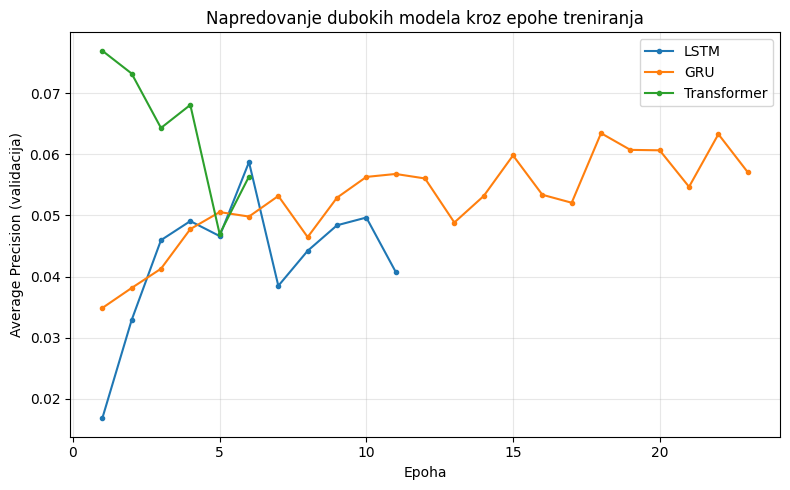

Grafik sačuvan: results/faza5_ap_kroz_epohe.png


In [ ]:
# --- 9. Grafik napredovanja AP na validaciji kroz epohe, za sva tri modela ---
# Zahvaljujući ranom zaustavljanju modeli mogu da se treniraju različit broj
# epoha, zato se za svaki model crta njegova sopstvena dužina istorije.
plt.figure(figsize=(8, 5))
for naziv_modela, ap_niz in istorije.items():
    plt.plot(
        range(1, len(ap_niz) + 1), ap_niz, marker="o", markersize=3, label=naziv_modela
    )
plt.xlabel("Epoha")
plt.ylabel("Average Precision (validacija)")
plt.title("Napredovanje dubokih modela kroz epohe treniranja")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / "faza5_ap_kroz_epohe.png", dpi=120)
plt.show()
print("Grafik sačuvan: results/faza5_ap_kroz_epohe.png")

# Kriva Transformera je znatno nestabilnija kroz epohe od LSTM-a i GRU-a. Ovo ponašanje
# je tipično za attention-bazirane modele na malim skupovima podataka (101 pozitivnih),
# gde svaka epoha vidi drugačiji raspored gradijenata. Rano zaustavljanje
# (strpljenje=5) je ovde posebno bitno da se ne zadrži slučajno loša epoha.


Najbolji duboki model: Transformer
Izabrani prag: 0.954763
Na validaciji -> preciznost: 0.1038, odziv: 0.2870, F1: 0.1524


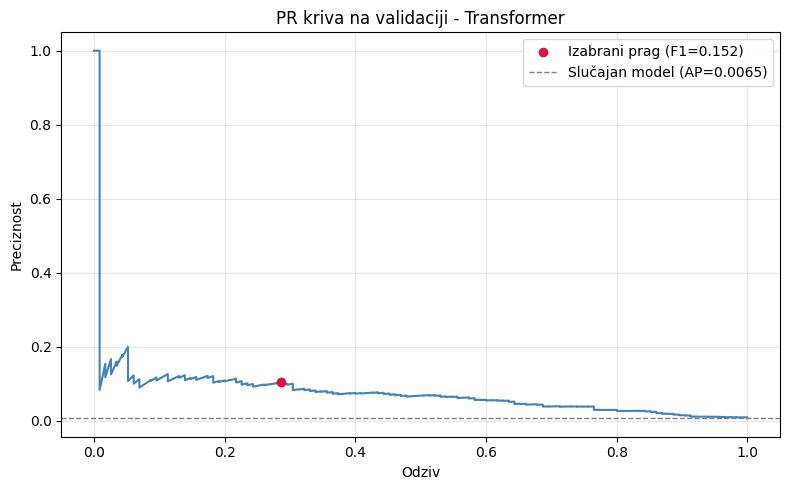

Grafik sačuvan: results/faza5_pr_kriva_validacije.png


In [ ]:
# --- 10. Biranje najboljeg modela i praga odlučivanja (isti postupak kao u Fazi 4) ---
naziv_najboljeg = duboki_rezultati.iloc[0]["Model"]
model_najbolji = modeli[naziv_najboljeg]

p_val, ap_val_najboljeg, auc_val_najboljeg = evaluiraj_model(model_najbolji, val_loader)

preciznost, odziv, pragovi = precision_recall_curve(y_val, p_val)
f1 = 2 * preciznost * odziv / (preciznost + odziv + 1e-12)
najbolji_idx = int(np.argmax(f1[:-1]))
prag = float(pragovi[najbolji_idx])

print(f"\nNajbolji duboki model: {naziv_najboljeg}")
print(f"Izabrani prag: {prag:.6f}")
print(
    f"Na validaciji -> preciznost: {preciznost[najbolji_idx]:.4f}, "
    f"odziv: {odziv[najbolji_idx]:.4f}, F1: {f1[najbolji_idx]:.4f}"
)

plt.figure(figsize=(8, 5))
plt.plot(odziv, preciznost, color="steelblue")
plt.scatter(
    odziv[najbolji_idx],
    preciznost[najbolji_idx],
    color="crimson",
    zorder=5,
    label=f"Izabrani prag (F1={f1[najbolji_idx]:.3f})",
)
plt.axhline(
    y_val.mean(),
    color="gray",
    linestyle="--",
    linewidth=1,
    label=f"Slučajan model (AP={y_val.mean():.4f})",
)
plt.xlabel("Odziv")
plt.ylabel("Preciznost")
plt.title(f"PR kriva na validaciji - {naziv_najboljeg}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / "faza5_pr_kriva_validacije.png", dpi=120)
plt.show()
print("Grafik sačuvan: results/faza5_pr_kriva_validacije.png")

# F1=0.1524 je znatno niži od Random Forest rezultata iz Faze 4 (F1=0.2969),
# što je dosledno nižem AP-u Transformera. Neobično visok prag (0.9548)
# sugeriše da Transformer daje ekstremno samouverene verovatnoće (blizu 0 ili 1).